In [ ]:
# Install the torchmetrics package for storing loss, evaluation metrics, etc.
!pip install lightning-utilities

In [ ]:
# Install the torchmetrics package for storing loss, evaluation metrics,etc.
!pip install torchmetrics --no-deps
# Install the torchinfo package for showing the network information
!pip install torchinfo --no-deps
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 961.5/961.5 kB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 124.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 99.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 52.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 43.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 79.5 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninsta

In [ ]:
import os
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
import torch
import torch.nn as nn
import torchvision
from torch.utils.data import random_split
from torchvision.transforms import v2
from torchvision.transforms.functional import to_pil_image
from torchmetrics import MeanMetric, Accuracy
from torchmetrics import ConfusionMatrix, Accuracy, Precision, Recall, F1Score

In [ ]:
# Make sure to change runtime to GPU
# Check if GPU is avaiable
device = "cuda" if torch.cuda.is_available() \
else "mps" if torch.mps.is_available() \
else "cpu"
print("Device:", device)

Device: cuda


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ascanipek/skin-diseases")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/skin-diseases


In [ ]:
#unzip a zip file
#!unzip archive\ \(1\).zip -d skin-disease

In [ ]:
#Augemtation for train
train_transform = v2.Compose([
    v2.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5), #Adjust color
    v2.RandomHorizontalFlip(p=0.5), # Random Horizontal split
    v2.RandomResizedCrop(size=224,  scale=(0.5, 1.0)), #Random crop and resize
    v2.ToImage(), #pytorch Image format
    v2.ToDtype(torch.float32, scale=True), #convert to tensor
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) #Normalize
])

In [ ]:
# data augmentation for validation and test
eval_transform = v2.Compose([
  v2.Resize((224, 224)), # resize image to 224
  v2.ToImage(), # PyTorch Image format
  v2.ToDtype(torch.float32, scale=True), # Convert to tensor
  v2.Normalize(mean=[0.485, 0.456, 0.406],
               std=[0.229, 0.224, 0.225]), # Normalize
])

In [ ]:
# Read datasets
train_data = torchvision.datasets.ImageFolder("/kaggle/input/skin-diseases/kaggle/train", transform=train_transform)
val_data = torchvision.datasets.ImageFolder("/kaggle/input/skin-diseases/kaggle/train", transform=eval_transform)
test_set = torchvision.datasets.ImageFolder("/kaggle/input/skin-diseases/kaggle/test", transform=eval_transform)

In [ ]:
#split the original train data into training (80%) and validation (20%)
#Random split (only splitting indices, datasets are independent)
train_size = int(0.8 * len(train_data))
val_size = len(train_data) - train_size
train_indices, val_indices = torch.utils.data.random_split(range(len(train_data)),
[train_size,val_size])
# train_data and val_data have different transforms
train_set = torch.utils.data.Subset(train_data, train_indices)
#val_set = torch.utils.data.Subset(val_data, val_indices)
val_set = torch.utils.data.Subset(val_data, torch.utils.data.random_split(range(len(val_data)), [val_size, len(val_data)-val_size])[0])

In [ ]:
# Define the classes
classes = ["infectious skin diseases", "Eczema", "Acne", "Pigment Diseases", "Benign", "Malign"]

num_class = len(classes)
print("Number of classes:", num_class)

Number of classes: 6


In [ ]:
# Define the data loaders for the training, validation, and test sets
train_dataloader = torch.utils.data.DataLoader(train_set, batch_size=64, shuffle=True)
val_dataloader = torch.utils.data.DataLoader(val_set, batch_size=64, shuffle=False)
test_dataloader = torch.utils.data.DataLoader(test_set, batch_size=64, shuffle=False)

In [ ]:
print("number of train samples:", len(train_set))
print("number of val samples:", len(val_set))
print("number of test samples:", len(test_set))

number of train samples: 24727
number of val samples: 6182
number of test samples: 3928


In [ ]:
def count_class_sample_number(dataset, classes):
# Get the labels of all the data in the training set
  labels = [dataset[i][1] for i in range(len(dataset))]
  # Count the number of data per class
  class_counts = np.bincount(labels)
  # Print the number of samples per class
  for class_label, count in enumerate(class_counts):
    print("Class", classes[class_label], "has", count, "samples.")



In [ ]:
  print("Train:")
  count_class_sample_number(train_set, classes)
  print("Validation:")
  count_class_sample_number(val_set, classes)
  print("Test:")
  count_class_sample_number(test_set, classes)

Train:
Class infectious skin diseases has 4795 samples.
Class Eczema has 3289 samples.
Class Acne has 1745 samples.
Class Pigment Diseases has 810 samples.
Class Benign has 8686 samples.
Class Malign has 5402 samples.
Validation:
Class infectious skin diseases has 1179 samples.
Class Eczema has 822 samples.
Class Acne has 418 samples.
Class Pigment Diseases has 215 samples.
Class Benign has 2168 samples.
Class Malign has 1380 samples.
Test:
Class infectious skin diseases has 750 samples.
Class Eczema has 510 samples.
Class Acne has 322 samples.
Class Pigment Diseases has 136 samples.
Class Benign has 1361 samples.
Class Malign has 849 samples.


In [ ]:
#adjust the class weights in the loss function to penalize the model more for misclassifying minority classes
# Class frequencies in my dataset (from my training data)
class_counts = np.array([4795, 3289, 1745, 810, 8686, 5402]) # distribution of training

# Calculate the inverse frequency for each class
inverse_weights = 1.0 / class_counts

# Normalize weights (optional step, sums to 1.0 for balance)
normalized_weights = inverse_weights / np.sum(inverse_weights)

# Convert to a tensor for use with the PyTorch loss function
class_weights = torch.tensor(normalized_weights, dtype=torch.float)

print(class_weights)

tensor([0.0796, 0.1160, 0.2187, 0.4711, 0.0439, 0.0706])


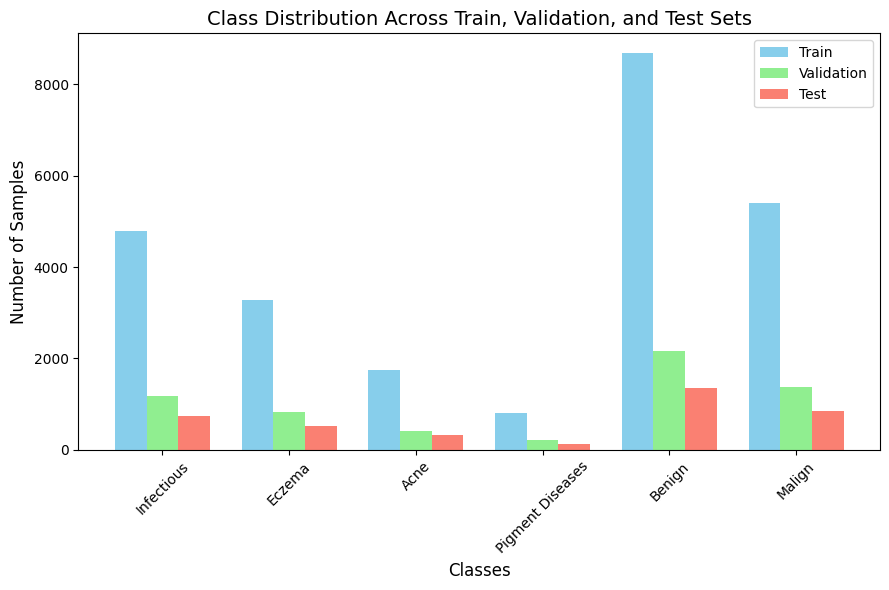

In [ ]:
import matplotlib.pyplot as plt

# Class names
classes = [
    "Infectious", "Eczema", "Acne",
    "Pigment Diseases", "Benign", "Malign"
]

# Sample counts for Train, Validation, Test
train_counts = [4795, 3289, 1745, 810, 8686, 5402]
val_counts = [1179, 822, 418, 215, 2168, 1380]
test_counts = [750, 510, 322, 136, 1361, 849]

# Bar width and positions
bar_width = 0.25
r1 = range(len(classes))
r2 = [x + bar_width for x in r1]
r3 = [x + bar_width for x in r2]

# Create bar chart
plt.figure(figsize=(9, 6))
plt.bar(r1, train_counts, color='skyblue', width=bar_width, label='Train')
plt.bar(r2, val_counts, color='lightgreen', width=bar_width, label='Validation')
plt.bar(r3, test_counts, color='salmon', width=bar_width, label='Test')

# Labels and titles
plt.xlabel('Classes', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.title('Class Distribution Across Train, Validation, and Test Sets', fontsize=14)
plt.xticks([r + bar_width for r in range(len(classes))], classes, rotation=45)
plt.legend()
plt.tight_layout()

# Show plot
plt.show()


In [ ]:
import os
import numpy as np
import pandas as pd
from PIL import Image

def get_image_stats(dataset):
    """
    Calculates descriptive statistics for an ImageFolder dataset.

    Args:
        dataset: A torchvision.datasets.ImageFolder object.

    Returns:
        A pandas DataFrame containing the statistics.
    """

    image_paths = [img[0] for img in dataset.imgs]  # Get all image paths
    widths = []
    heights = []
    labels = []

    # Calculate image size statistics
    for image_path in image_paths:
        with Image.open(image_path) as img:
            width, height = img.size
            widths.append(width)
            heights.append(height)

    # Create a DataFrame
    stats_df = pd.DataFrame({
        'Width': widths,
        'Height': heights,

    })

    # Calculate summary statistics
    summary_stats = stats_df.describe()

    return summary_stats


# Get descriptive statistics for your train_data
image_stats = get_image_stats(train_data)
#print(image_stats)
image_stats
# You can also calculate color channel statistics using a similar approach:
# 1. Load each image using PIL.Image.open()
# 2. Convert the image to a NumPy array using np.array()
# 3. Calculate mean and standard deviation for each color channel (R, G, B) using np.mean() and np.std()
# 4. Store the results in a DataFrame or dictionary.

,Width,Height
count,30909.000000,30909.000000
mean,670.060824,556.648872
std,215.815475,223.427974
min,80.000000,29.000000
25%,512.000000,450.000000
50%,720.000000,477.000000
75%,720.000000,680.000000
max,5573.000000,4028.000000


In [ ]:
# Define denormalization transform
def denormalize(tensor):
  # Reshape to match image dimensions
  mean = torch.tensor([0.485, 0.456, 0.406]).reshape(3, 1, 1)
  std = torch.tensor([0.229, 0.224, 0.225]).reshape(3, 1, 1)
  return tensor * std + mean # Reverse normalization
  # function: Visualize training image for each class
def visualize_data(dataset, classes, transform=None):
  sample_images = []
  # Find one image per class
  for class_i in range(len(classes)):
  # ImageFolder dataset.imgs stores (image_path, label)
    for image_path, label in dataset.imgs:
      if label == class_i:
        image = Image.open(image_path)
        if transform:
          image = transform(image) # data augmentation
          image = denormalize(image) # denormalize
          # convert back to PIL image format
          image = to_pil_image(image.clamp(0, 1))
        sample_images.append(image)
        break # Stop after finding one image per class
  # Show images
  fig, axes = plt.subplots(1, len(classes), figsize=(16, 4))
  for i, axis in enumerate(axes.flat):
    axis.set_xticks([])
    axis.set_yticks([])
    axis.set_xlabel(classes[i], fontsize=12)
    axis.imshow(sample_images[i])


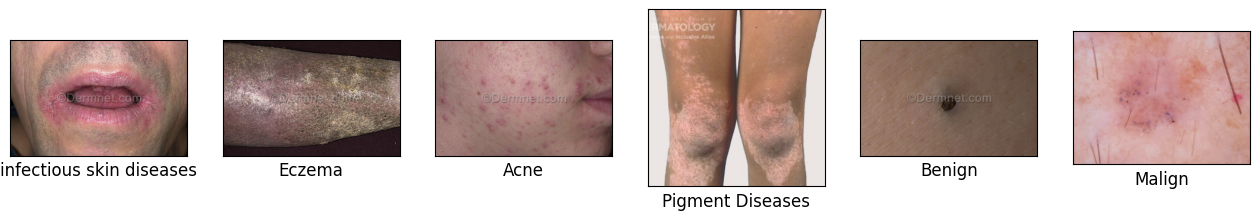

In [ ]:
visualize_data(train_data, classes)


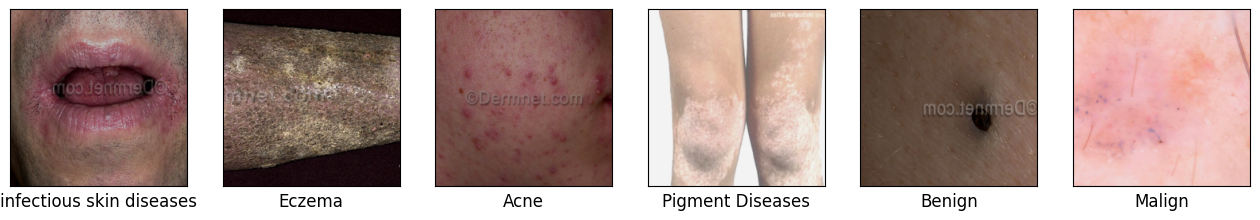

In [ ]:
visualize_data(train_data, classes, train_transform)

Model 1(resnet18)

In [ ]:
# get a pretrain resnet18
model = torchvision.models.resnet18(weights='IMAGENET1K_V1')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 214MB/s]


In [ ]:
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
# Add a new layer/change the last layer
model.fc = nn.Linear(model.fc.in_features, num_class)

In [ ]:
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
# Move model to GPU
model = model.to(device)

In [ ]:
# Specify loss function (categorical cross-entropy) with class weight
criteria = torch.nn.CrossEntropyLoss(weight=class_weights.to(device))

In [ ]:
# Specify optimizer (Adam) and learning rate = 0.001
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0001)

Experiment

In [ ]:
# a function for training one epoch
def train_one_epoch(model, dataloader):
  # Prepare for storing loss and accuracy
  losses = MeanMetric().to(device)
  acc = Accuracy(task='multiclass', num_classes=6).to(device)
  model.train() # set model to train mode
  # a loop to iterate input(X) and label(Y) for all mini-batches
  for X, Y in tqdm(dataloader):
    X = X.to(device)
    Y = Y.to(device)
    optimizer.zero_grad() # reset optimizer
    preds = model(X) # model forward
    loss = criteria(preds, Y) # calculate loss
    loss.backward() # compute gradients via backpropagation
    optimizer.step() # perform gradient descent
    preds = preds.argmax(dim=1) # obtain the final predicted class
    losses.update(loss, X.size(0)) # store loss per batch
    acc.update(preds, Y) # store accuracy per batch
  return losses.compute().item(), acc.compute().item()

In [ ]:
# a function for validation one epoch
def validation_one_epoch(model, dataloader):
  # Prepare for storing loss and accuracy
  losses = MeanMetric().to(device)
  acc = Accuracy(task='multiclass', num_classes=6).to(device)
  model.eval() # set model to validation mode
  with torch.no_grad(): # disables gradient computation for evaluation
    # a loop to iterate input(X) and label(Y) for all mini-batches
    for X, Y in tqdm(dataloader):
      X = X.to(device)
      Y = Y.to(device)
      preds = model(X) # model forward
      loss = criteria(preds, Y) # calculate loss
      preds = preds.argmax(dim=1) # obtain the final predicted class
      losses.update(loss, X.size(0)) # store loss per batch
      acc.update(preds, Y) # store accuracy per batch
  return losses.compute().item(), acc.compute().item()

In [ ]:
# Prepare for storing loss and accuracy
history = pd.DataFrame() # store statics for each epoch
epochs = 10 # number of epochs
# a loop for epochs
for i in range(0, epochs):
  # train one epoch
  train_loss, train_acc = train_one_epoch(model, train_dataloader)
  # validation one epoch
  val_loss, val_acc = validation_one_epoch(model, val_dataloader)
  # store and print loss and accuracy per epoch
  statistics = pd.DataFrame({
      "epoch": [i],   "train_loss": [train_loss],
                      "train_acc": [train_acc],
                      "val_loss": [val_loss],
                      "val_acc": [val_acc]})
  history = pd.concat([history, statistics], ignore_index=True)
  print(statistics.to_dict(orient="records")[0])

100%|██████████| 97/97 [00:57<00:00,  1.68it/s]


{'epoch': 0, 'train_loss': 0.8918831944465637, 'train_acc': 0.6585513949394226, 'val_loss': 0.7032318711280823, 'val_acc': 0.714817225933075}


100%|██████████| 97/97 [01:00<00:00,  1.60it/s]


{'epoch': 1, 'train_loss': 0.6635234355926514, 'train_acc': 0.7435596585273743, 'val_loss': 0.6010912656784058, 'val_acc': 0.7672274112701416}


100%|██████████| 97/97 [00:58<00:00,  1.65it/s]


...

{'epoch': 7, 'train_loss': 0.28902095556259155, 'train_acc': 0.8813442587852478, 'val_loss': 0.3196060061454773, 'val_acc': 0.8872533440589905}


100%|██████████| 97/97 [00:57<00:00,  1.68it/s]


{'epoch': 8, 'train_loss': 0.2558372914791107, 'train_acc': 0.8927892446517944, 'val_loss': 0.32262852787971497, 'val_acc': 0.888870894908905}


100%|██████████| 97/97 [00:56<00:00,  1.71it/s]

{'epoch': 9, 'train_loss': 0.224860280752182, 'train_acc': 0.906175434589386, 'val_loss': 0.3066224455833435, 'val_acc': 0.8979294896125793}


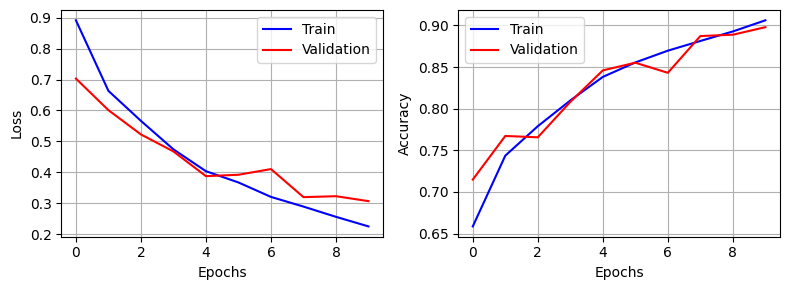

In [ ]:
# Create a figure with two subplots (side by side)
plt.figure(figsize=(8, 3))
# Plot Loss Curve (Train + Validation)
plt.subplot(1, 2, 1)  # 1 row, 2 columns, first plot
plt.plot(history["epoch"], history["train_loss"], label="Train", color="blue")
plt.plot(history["epoch"], history["val_loss"], label="Validation", color="red")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
# Plot Accuracy Curve (Train + Validation)
plt.subplot(1, 2, 2)  # 1 row, 2 columns, second plot
plt.plot(history["epoch"], history["train_acc"], label="Train", color="blue")
plt.plot(history["epoch"], history["val_acc"], label="Validation", color="red")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
# Adjust layout and show the plots
plt.tight_layout()
plt.show()

Final Test

In [ ]:
# prepare for storing evaluation metrics
test_acc = Accuracy(task='multiclass', num_classes=num_class).to(device)
test_confusion_matrix=ConfusionMatrix(task="multiclass", num_classes=num_class).to(device)
test_precision = Precision(task="multiclass", num_classes=num_class, average="macro").to(device)
test_recall = Recall(task="multiclass", num_classes=num_class, average="macro").to(device)
test_f1_score = F1Score(task="multiclass", num_classes=num_class, average="macro").to(device)

model = model.to(device)
model.eval() # set model to evaluation mode
with torch.no_grad():
  for X, Y in test_dataloader:
    X = X.to(device)
    Y = Y.to(device)
    preds = model(X) # model forward
    preds = preds.argmax(dim=1) # obtain the final predicted class
    # store loss and accuracy per batc
    test_confusion_matrix.update(preds, Y)
    test_acc.update(preds, Y)
    test_precision.update(preds, Y)
    test_recall.update(preds, Y)
    test_f1_score.update(preds, Y)
  # Print the results
  print("Confusion Matrix:\n", test_confusion_matrix.compute())
  print("Accuracy:", test_acc.compute().item())
  print("Precision:", test_precision.compute().item())
  print("Recall:", test_recall.compute().item())
  print("F1 Score:", test_f1_score.compute().item())

Confusion Matrix:
 tensor([[ 659,   42,   11,   21,    8,    9],
        [  56,  407,    7,   21,    4,   15],
        [  18,    2,  290,    6,    2,    4],
        [  15,    9,    2,  105,    0,    5],
        [  83,    6,    7,   11, 1116,  138],
        [  31,   10,    3,   15,   68,  722]], device='cuda:0')
Accuracy: 0.8398675918579102
Precision: 0.8087414503097534
Recall: 0.8366305232048035
F1 Score: 0.819069504737854


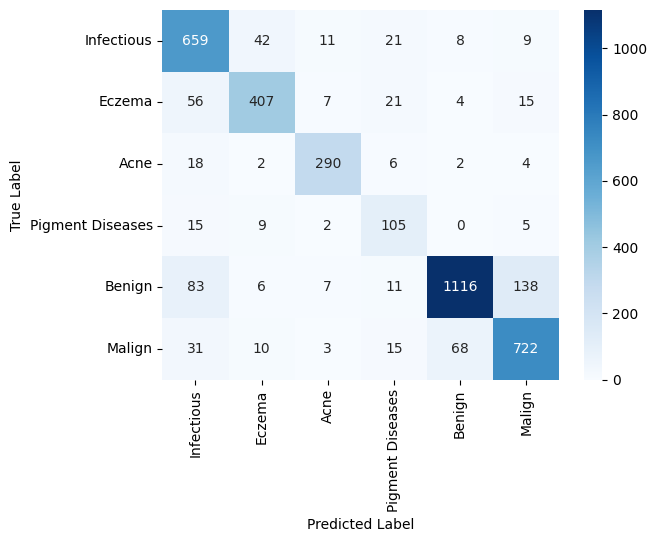

In [ ]:
# Create a heatmap for better confusion matrix visualization
sns.heatmap(test_confusion_matrix.compute().cpu(), annot=True, fmt="d",
            cmap="Blues", xticklabels=classes, yticklabels=classes)
# Labels and title
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()